У цьому ДЗ ми попрактикуємось моделювати часові ряди на даних з [Store Item Demand Forecasting Challenge](https://www.kaggle.com/competitions/demand-forecasting-kernels-only/overview). Ми будемо працювати лише з тренувальними даними цього змагання і задача у нас буде дещо змінена. Фокус буде на пошуці найкращої моделі, експериментах і використанні функціоналу `darts`.

Якщо якісно попрацювати в цьому завданні - це буде чудовий приклад проєкту для вашого портфоліо: "спрогнозував(-ла) поденні продажі на 1 міс для 50 товарів в 10 магазинах" звучить вражаюче! Але ми в рамках ДЗ для оптимізації часу сконцентруємось на моделюванні продажів одного товару в одному магазині.

**Задача**

Вам надано дані про продажі товарів у магазинах за 5 років. Хочемо навчитись передачати продажі в наступному місяці поденно кожного з 50 товарів у кожному з 10 магазинів. Відповідно будемо проводити експерименти, аби знайти найкращу модель для цього.

На відміну від змагання, ми будемо використовувати метрику МАРЕ (Mean Absolute Percentage Error) замість SMAPE (Symmetric Mean Absolute Percentage Error). Проте, ви також можете розрахувати SMAPE і подати свої результати через late submission на Kaggle.

1. Завантажуємо дані в Pandas.

  1. Завантажте дані з файлу `train.csv.zip` за допомогою бібліотеки Pandas.
  2. Перетворіть колонку `date` на формат `datetime`.
  3. Встановіть колонку `date` як індекс для датафрейму.
  4. Виведіть перші 10 рядків отриманого датафрейму та інформацію про датафрейм.

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import plotly.express as px
import seaborn as sns

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_predict

In [2]:
data = pd.read_csv('data_time/train.csv.zip')
display(data.head())

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [3]:
data['date'] = pd.to_datetime(data['date'])
data.set_index('date', inplace=True)

In [4]:
display(data.head(10))

,store,item,sales
date,,,
2013-01-01,1,1,13
2013-01-02,1,1,11
2013-01-03,1,1,14
2013-01-04,1,1,13
2013-01-05,1,1,10
2013-01-06,1,1,12
2013-01-07,1,1,10
2013-01-08,1,1,9
2013-01-09,1,1,12


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 913000 entries, 2013-01-01 to 2017-12-31
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   store   913000 non-null  int64
 1   item    913000 non-null  int64
 2   sales   913000 non-null  int64
dtypes: int64(3)
memory usage: 27.9 MB


  2. Давайте трошки зрозуміємо дані. У нас 10 магазинів і 50 айтемів в кожному. Хочемо зрозуміти, чи відрізняється динаміка по кожному айтему в магазинах. Як би ви це візуалізували? Побудуйте 3 графіка, які вам допоможуть. Можна використати будь-який інструмент: matplotlib, seaborn, plotly.

  Напишіть висновок з побудованих вами візуалізацій.
  
    **Підказка**: я б спробувала вивести середнє значення і довірчий інтервал (який включає весь діапазон значень з різних магазинів) для динаміки кожного айтема, або принаймні для декількох айтемів, аби зрозуміти тенденцію.



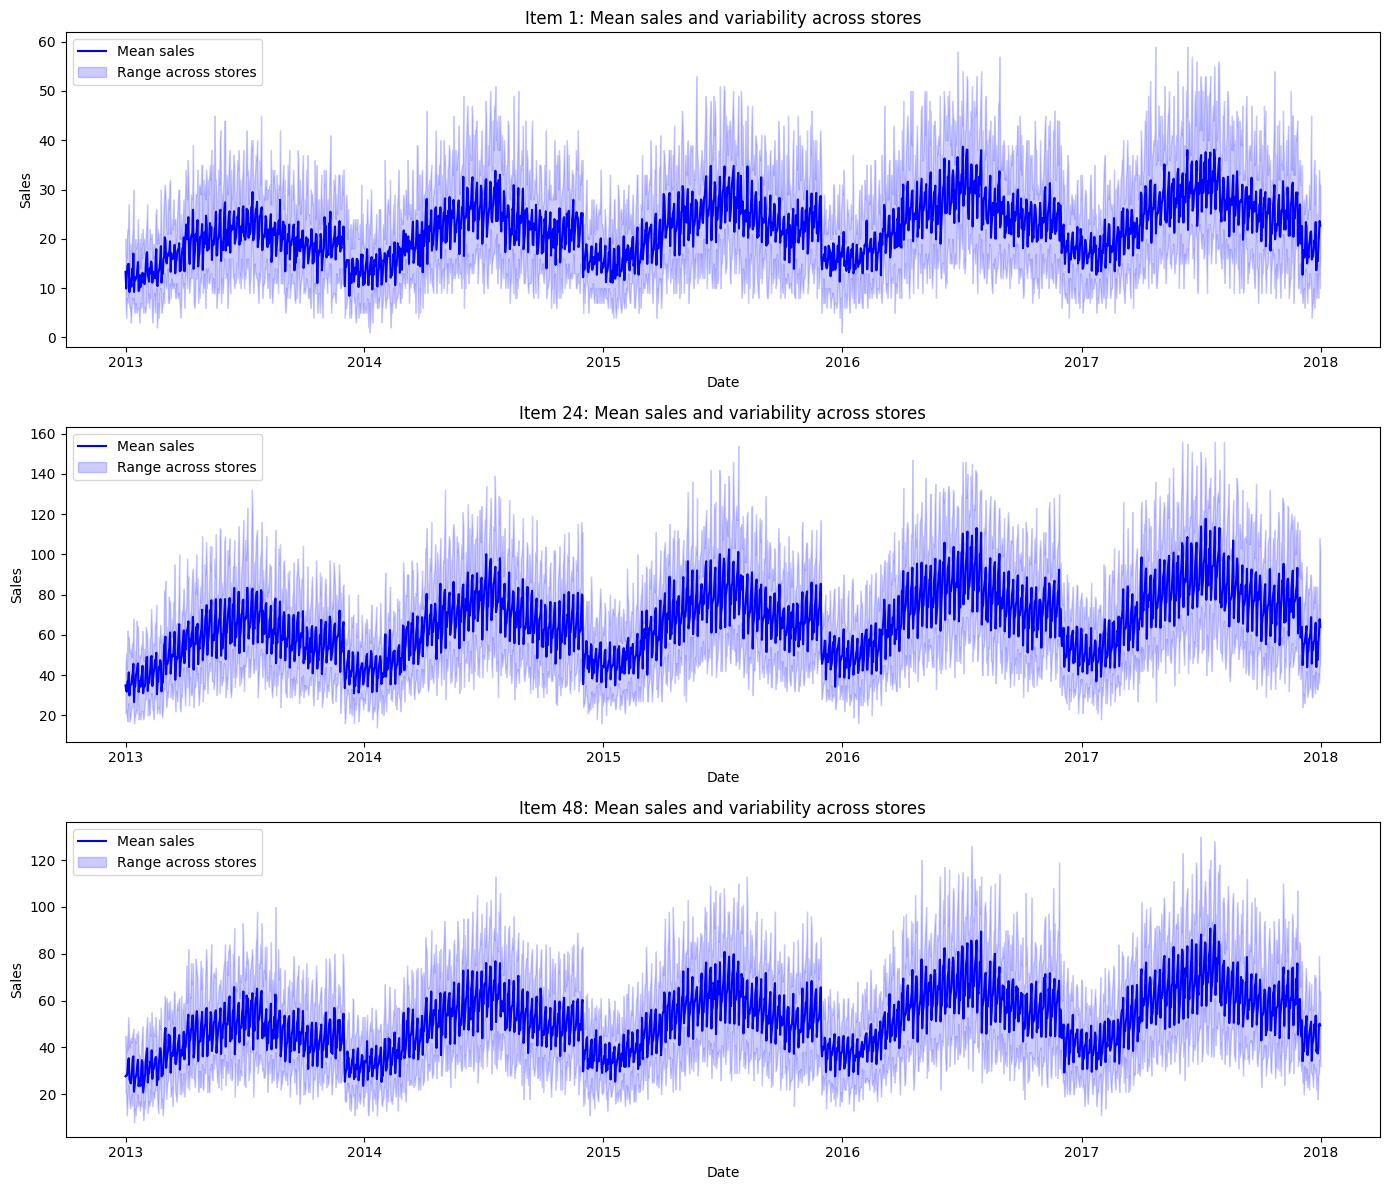

In [6]:
items_to_plot = [1, 24, 48]
n_items = len(items_to_plot)

plt.figure(figsize=(14, 4 * n_items))

for i, item_id in enumerate(items_to_plot, 1):
    df_item = data[data['item'] == item_id]

    # Групуємо по даті
    daily_stats = df_item.groupby(df_item.index)['sales'].agg(['mean', 'min', 'max'])

    # Subplot
    plt.subplot(n_items, 1, i)
    plt.plot(daily_stats.index, daily_stats['mean'], label='Mean sales', color='blue')
    plt.fill_between(daily_stats.index, daily_stats['min'], daily_stats['max'],
                     color='blue', alpha=0.2, label='Range across stores')

    plt.title(f"Item {item_id}: Mean sales and variability across stores")
    plt.xlabel("Date")
    plt.ylabel("Sales")
    plt.legend()

plt.tight_layout()
plt.show()


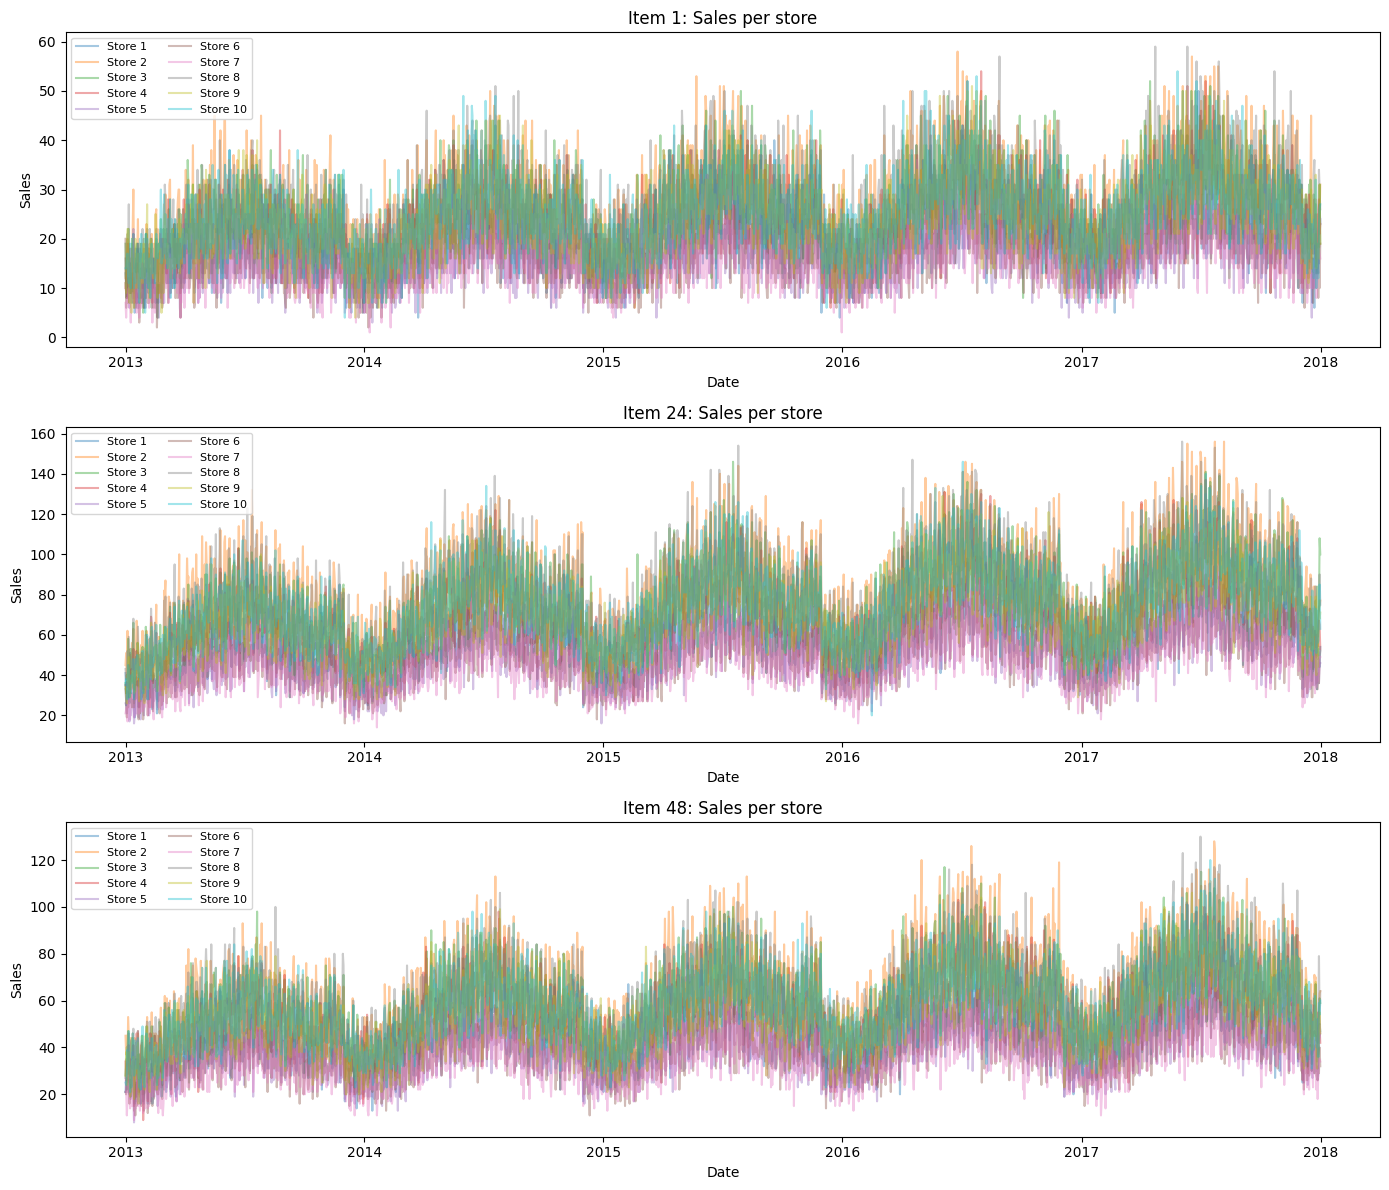

In [7]:
items_to_plot = [1, 24, 48]
n_items = len(items_to_plot)

plt.figure(figsize=(14, 4 * n_items))

for i, item_id in enumerate(items_to_plot, 1):
    df_item = data[data['item'] == item_id]

    plt.subplot(n_items, 1, i)

    # Лінії продажів по магазинах
    for store_id, df_store in df_item.groupby('store'):
        plt.plot(df_store.index, df_store['sales'], alpha=0.4, label=f"Store {store_id}")

    plt.title(f"Item {item_id}: Sales per store")
    plt.xlabel("Date")
    plt.ylabel("Sales")
    plt.legend(ncol=2, fontsize=8)

plt.tight_layout()
plt.show()


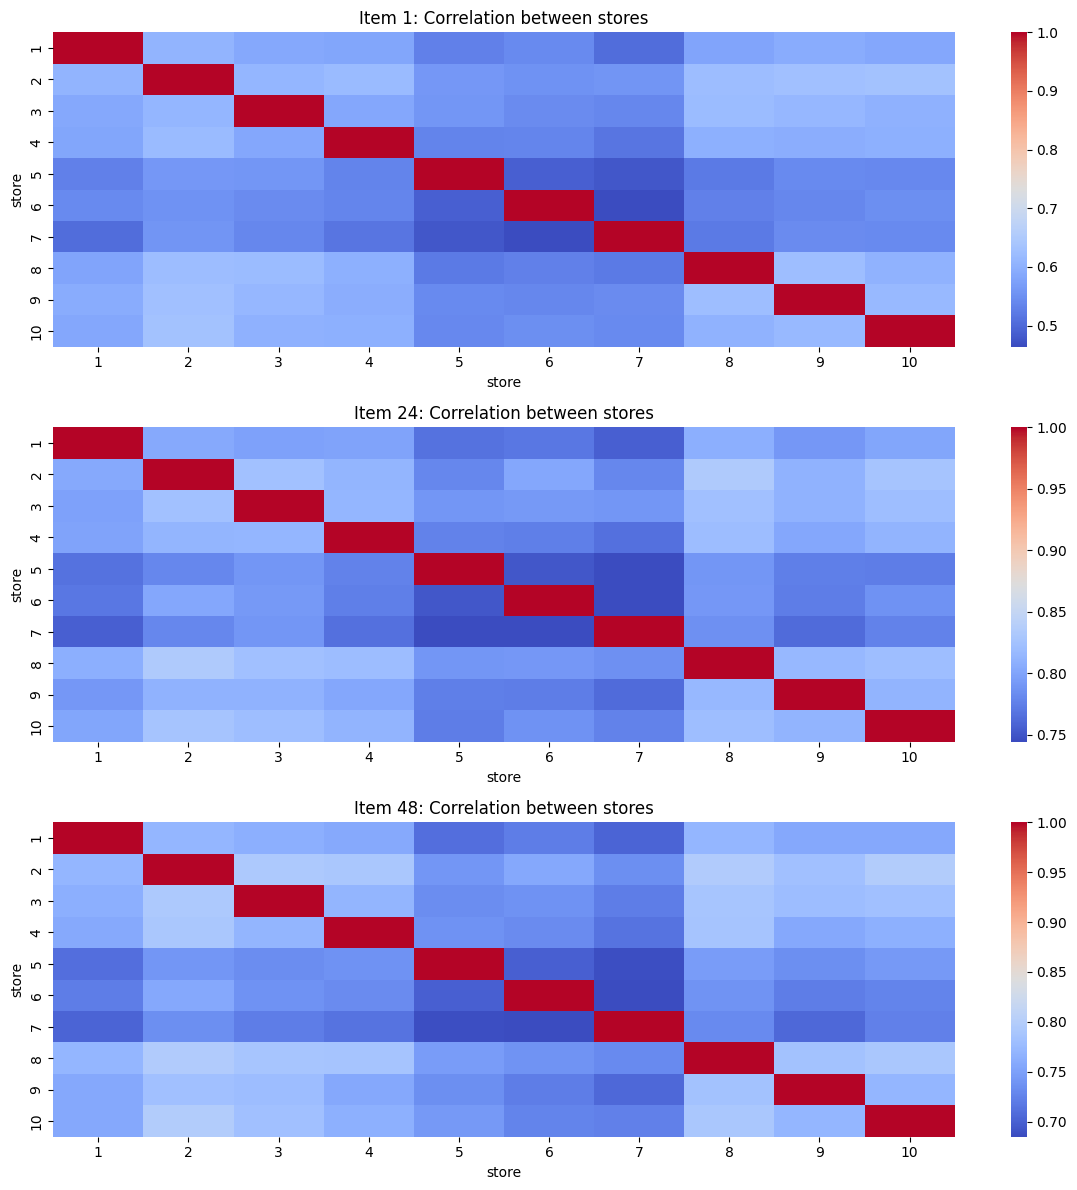

In [8]:
items_to_plot = [1, 24, 48]
n_items = len(items_to_plot)

plt.figure(figsize=(12, 4 * n_items))

for i, item_id in enumerate(items_to_plot, 1):
    df_item = data[data['item'] == item_id]

    # Півот: індекс = дата, колонки = магазини
    pivot = df_item.pivot_table(index=df_item.index, columns='store', values='sales')

    # Кореляційна матриця
    corr = pivot.corr()

    # Subplot
    plt.subplot(n_items, 1, i)
    sns.heatmap(corr, annot=False, cmap='coolwarm')
    plt.title(f"Item {item_id}: Correlation between stores")

plt.tight_layout()
plt.show()

**Висновок**
1. Чітко виражена сезонність
2. Величина продажів того самого товару поміж магазинами може дещо відріднятися, але сезонність при цьому доволі схожа
3. Поміж магазинами присутня помірно виражена кореляція для того самого товару

3. **Для початку проаналізуємо лише один ряд, а далі зможемо зациклити тренування моделей.**
  
  Виберіть підмножину даних, що відповідає продажам товару з `item == 1` у магазині з `store == 1`.

  Зробіть декомпозицію цього рядку за адитивною моделлю на тренд, сезонність і залишки з бібліотекою `statsmodels`.

  Зробіть висновки з отриманих візуалізацій. Чи щось би могло вам допомогти ліпше зрозуміти ці візуалізації? (з точки зору обробки даних)

In [9]:
df_1 = data[(data['item'] == 1) & (data['store'] == 1)].copy()
df_1 = df_1.sort_index()

<Figure size 1200x800 with 0 Axes>

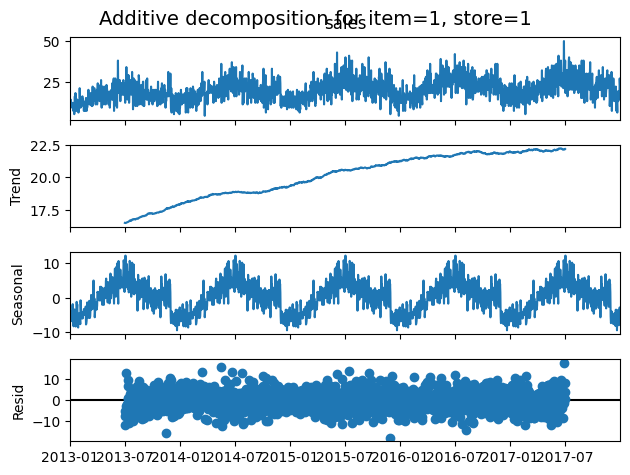

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(df_1['sales'], model='additive', period=365)

plt.figure(figsize=(12, 8))
result.plot()
plt.suptitle("Additive decomposition for item=1, store=1", fontsize=14)
plt.show()

**Висновок**
1. Оригінальний ряд (Sales) виглядає шумним, але з чіткими коливаннями.
2. Тренд плавно зростає з ~17 до ~22. Тренд не має різких стрибків - дані досить стабільні.
3. Сезонність чітка, регулярна, з амплітудою приблизно ±10. Виглядає як класична річна сезонність: піки в одні й ті самі місяці кожного року.
4. Залишки виглядають випадковими, без видимих структур.

Згладити ряд перед декомпозицією, ковзне середнє

<Figure size 1200x800 with 0 Axes>

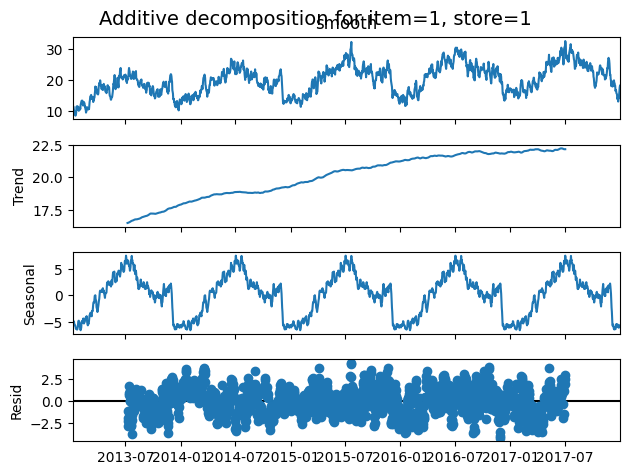

In [14]:
df_1['smooth'] = df_1['sales'].rolling(7).mean()
df_clean = df_1.dropna()

result = seasonal_decompose(df_clean['smooth'], model='additive', period=365)

plt.figure(figsize=(12, 8))
result.plot()
plt.suptitle("Additive decomposition for item=1, store=1", fontsize=14)
plt.show()

Ресемплінг, якщо дані дуже шумні, можна перейти на тижневі

<Figure size 1200x800 with 0 Axes>

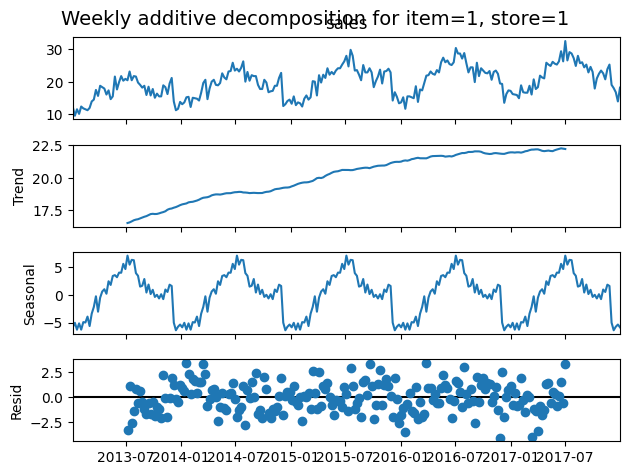

In [15]:
df_1_weekly = df_1['sales'].resample('W').mean()

result = seasonal_decompose(df_1_weekly, model='additive', period=52)

plt.figure(figsize=(12, 8))
result.plot()
plt.suptitle("Weekly additive decomposition for item=1, store=1", fontsize=14)
plt.show()

**Висновок**
1. Sales (оригінальний ряд). Коливання стали значно плавнішими. Видно чіткі хвилі, але без щоденного шуму.
2. Тренд зростає від ~17.5 до ~22.5. Він став ще чистішим, ніж у daily‑версії. Немає різких стрибків.
3. Тепер сезонність має амплітуду приблизно ±5. Вона стала більш регулярною.
4. Залишки виглядають випадковими. Немає видимих структур. Немає тренду в зaлишках.

4. Зі створеної підможени даних в попередньому пункті створіть обʼєкт класу `TimeSeries` в `darts` лише для колонки `sales`.

In [34]:
df_1 = df_1.asfreq("D")

In [35]:
from darts import TimeSeries

# Створення TimeSeries лише з колонки sales
ts_1 = TimeSeries.from_series(df_1['sales'])

In [36]:
ts_1

,sales
date,
2013-01-01,13.0
2013-01-02,11.0
2013-01-03,14.0
2013-01-04,13.0
2013-01-05,10.0
...,...
2017-12-27,14.0
2017-12-28,19.0
2017-12-29,15.0


5. Використовуючи метод `series.split_before` розбийте дані на тренування і валідацію так, аби валідація починалась з `2017-10-01` включно.

  Візуалізуйте на одному графіку тренувальну і валідаційну частину як було показано в лекції.

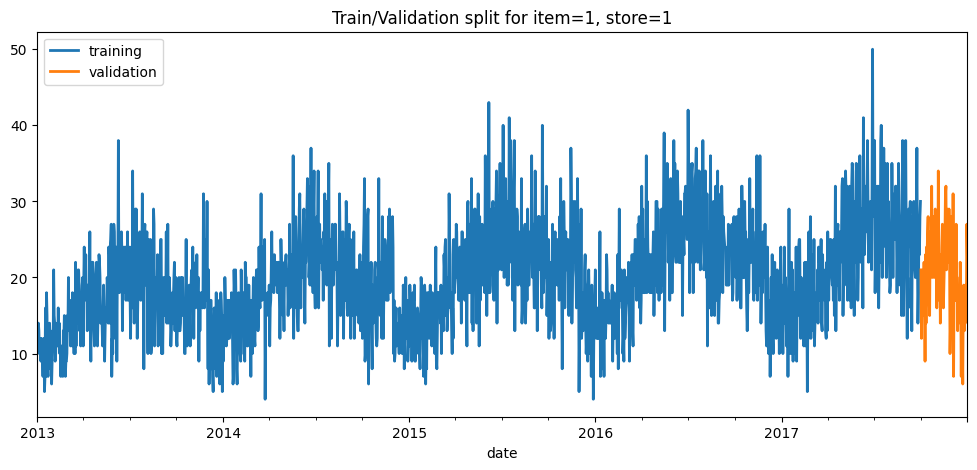

In [37]:
train, val = ts_1.split_before(pd.Timestamp("2017-10-01"))
plt.figure(figsize=(12, 5))

train.plot(label="training")
val.plot(label="validation")

plt.title("Train/Validation split for item=1, store=1")
plt.legend()
plt.show()

6. Побудуйте часткову автокореляційну фукнцію для цього нашого ряду в `series`. Напишіть висновки - які лаги є важливими для прогнозування?

In [38]:
series_pd = ts_1.to_series()

<Figure size 1000x600 with 0 Axes>

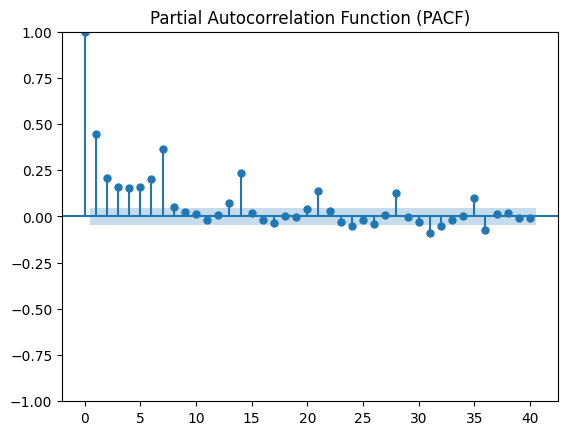

In [39]:
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(10, 6))
plot_pacf(series_pd, lags=40)
plt.title('Partial Autocorrelation Function (PACF)')
plt.show()

**Висновок**
- Лаг 1 - дуже значущий. Він виходить далеко за межі довірчого інтервалу. Це означає, що ряд має сильну AR(1) структуру.
- Лаг 7 - помітно значущий - тижнева сезонність у daily даних.

7. Виявіть сезональність тренувального ряду використовуючи фукнкцію `check_seasonality` з `darts`.

In [43]:
from darts.utils.statistics import plot_acf, check_seasonality

for m in range(2, 25):
    is_seasonal, period = check_seasonality(train, m=m, alpha=0.05)
    if is_seasonal:
        print("There is seasonality of order {}.".format(period))

There is seasonality of order 7.
There is seasonality of order 14.
There is seasonality of order 21.


8. Побудуйте наївну модель NaiveSeasonal + NaieDrift для прогнозування даних. Кількість кроків для прогнозування визначіть зі свого аналізу в попередніх пунктах. Візуалізайте передбачення проти справжніх даних так, аби було видно якість передбачень. Зробіть висновок про модель. Вона точна?

  Якщо у вас є ідеї, як поліпшити якість передбачення саме наївними моделями - реалізуйте їх в цьому пункті :)

In [44]:
from darts.models import NaiveSeasonal, NaiveDrift

# Довжина прогнозу
forecast_horizon = len(val)

# Моделі
seasonal_model = NaiveSeasonal(K=7)
drift_model = NaiveDrift()

# Навчання
seasonal_model.fit(train)
drift_model.fit(train)

# Прогнози
seasonal_forecast = seasonal_model.predict(forecast_horizon)
drift_forecast = drift_model.predict(forecast_horizon)

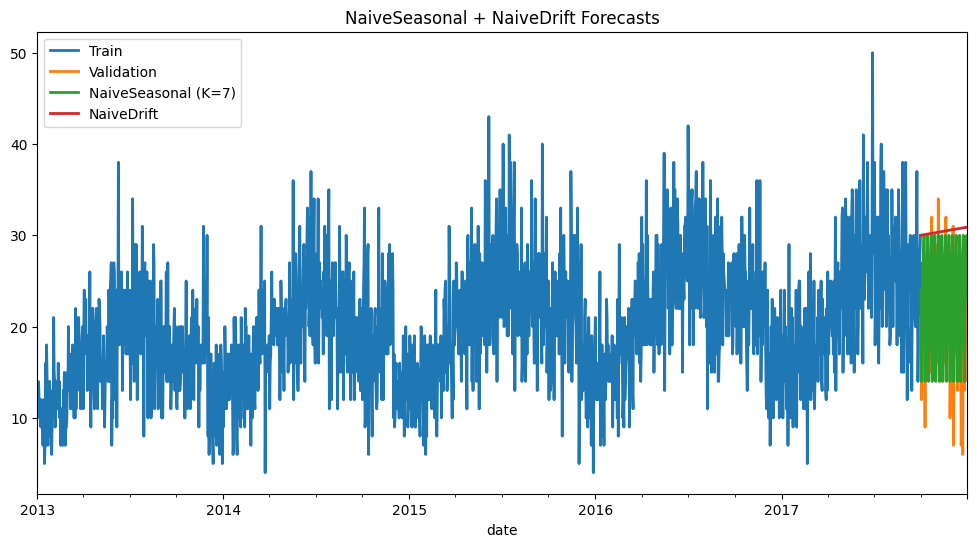

In [45]:
plt.figure(figsize=(12, 6))

train.plot(label="Train")
val.plot(label="Validation")
seasonal_forecast.plot(label="NaiveSeasonal (K=7)")
drift_forecast.plot(label="NaiveDrift")

plt.title("NaiveSeasonal + NaiveDrift Forecasts")
plt.legend()
plt.show()

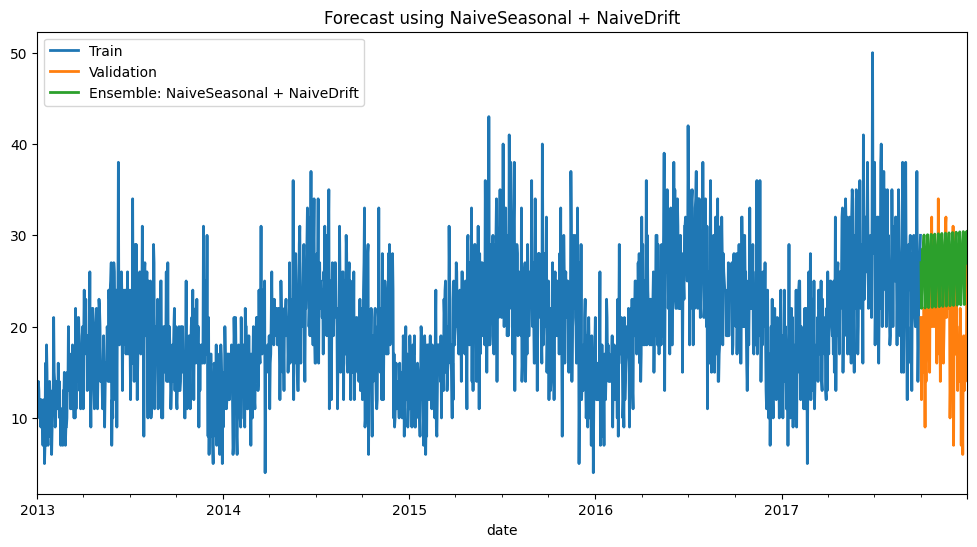

In [55]:
from darts.models import NaiveEnsembleModel

ensemble = NaiveEnsembleModel([NaiveSeasonal(K=7), NaiveDrift()])
ensemble.fit(train)
ensemble_forecast = ensemble.predict(forecast_horizon)

plt.figure(figsize=(12, 6))

train.plot(label="Train")
val.plot(label="Validation")
ensemble_forecast.plot(label="Ensemble: NaiveSeasonal + NaiveDrift")

plt.title("Forecast using NaiveSeasonal + NaiveDrift")
plt.legend()
plt.show()

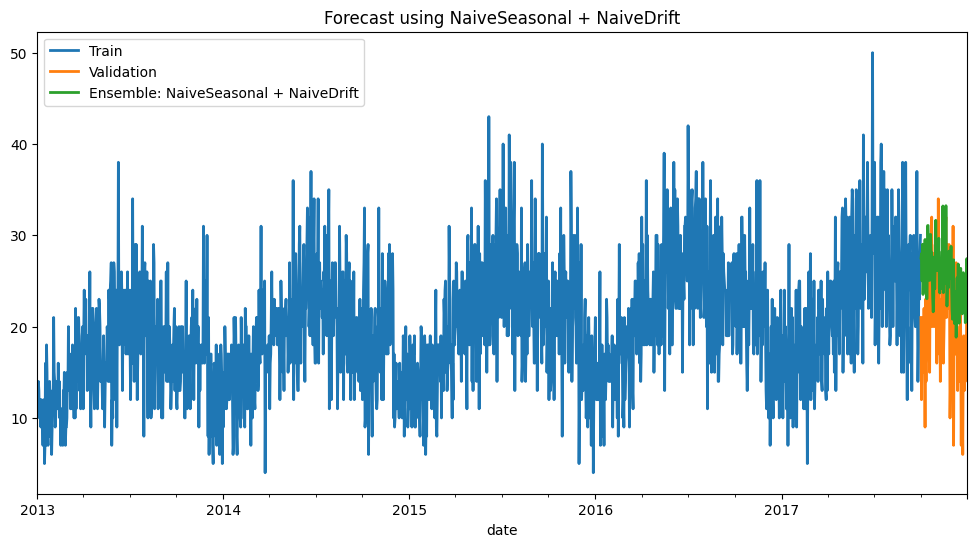

In [57]:
from darts.models import NaiveEnsembleModel

ensemble = NaiveEnsembleModel([NaiveSeasonal(K=365), NaiveDrift()])
ensemble.fit(train)
ensemble_forecast = ensemble.predict(forecast_horizon)

plt.figure(figsize=(12, 6))

train.plot(label="Train")
val.plot(label="Validation")
ensemble_forecast.plot(label="Ensemble: NaiveSeasonal + NaiveDrift")

plt.title("Forecast using NaiveSeasonal + NaiveDrift")
plt.legend()
plt.show()

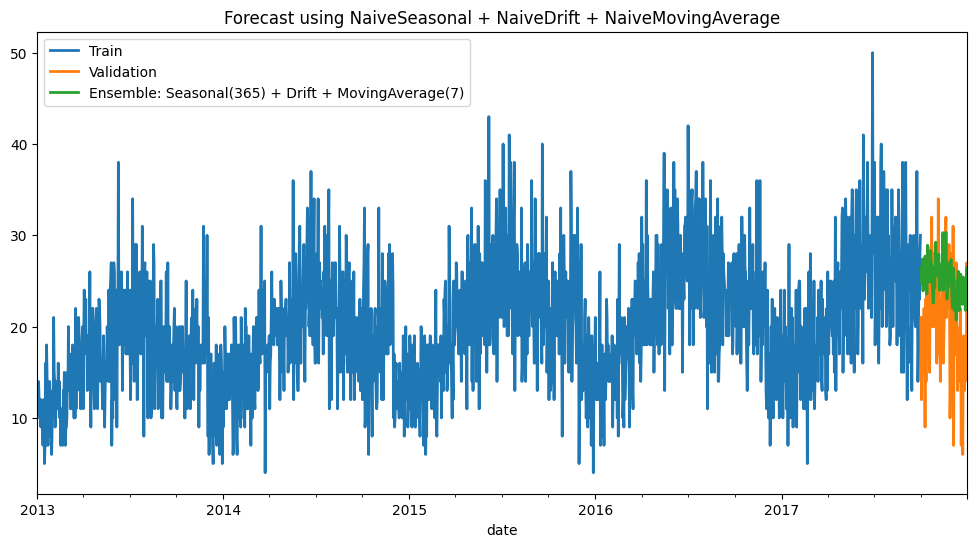

In [70]:
from darts.models import NaiveSeasonal, NaiveDrift, NaiveMovingAverage, NaiveEnsembleModel

# Моделі
seasonal_year = NaiveSeasonal(K=365)
drift = NaiveDrift()
moving_avg = NaiveMovingAverage(input_chunk_length=21)  # 21-денне ковзне середнє

# Ансамбль
ensemble = NaiveEnsembleModel([seasonal_year, drift, moving_avg])

# Навчання
ensemble.fit(train)

# Прогноз
ensemble_forecast = ensemble.predict(forecast_horizon)

plt.figure(figsize=(12, 6))

train.plot(label="Train")
val.plot(label="Validation")
ensemble_forecast.plot(label="Ensemble: Seasonal(365) + Drift + MovingAverage(7)")

plt.title("Forecast using NaiveSeasonal + NaiveDrift + NaiveMovingAverage")
plt.legend()
plt.show()

**Висновок**
Наївна модель не виглядає достатньо точною, вона дещо вловлює сезонність, але при цьому дещо завищує тренд.

9. Обчисліть помилку прогнозу на валідації наївною моделлю з mape. Далі для всіх моделей необхідно обчислювати помилку прогнозу на валідації.

In [71]:
def evaluate(model, train, val):
    model.fit(train)
    forecast = model.predict(len(val))
    return mape(val, forecast)

error = evaluate(ensemble, train, val)
print(f"MAPE ensemble: {error:.2f}%")

MAPE ensemble: 41.62%


10. Натренуйте XBGModel з `darts` для передбачення наших даних. Можна додавати всі додаткові ознаки, які вважаєте за потрібне, наприклад, ознаки з дати. Зробіть висновок про якість моделі.

`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.


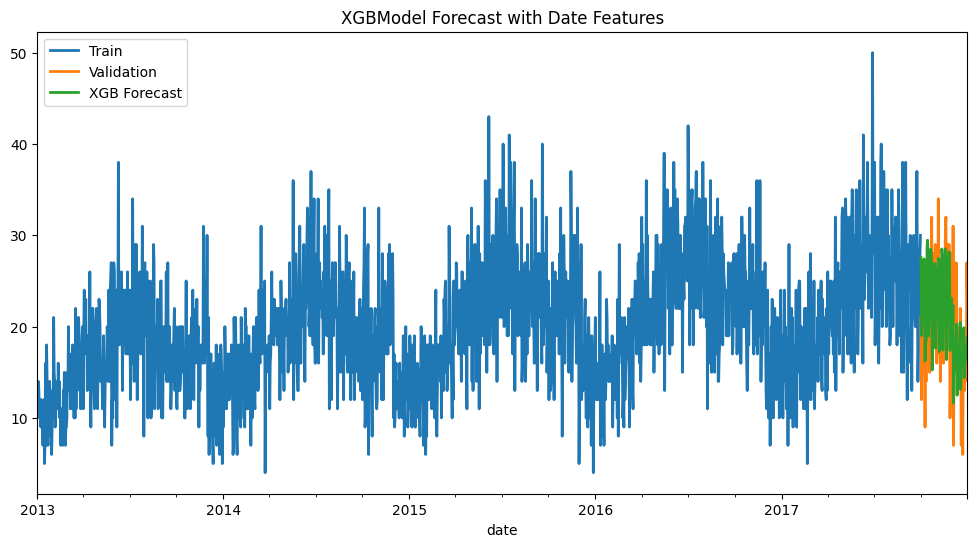

MAPE XGBModel: 24.36%


In [74]:
from darts import TimeSeries
from darts.models import XGBModel
from darts.dataprocessing.transformers import Scaler
from darts.metrics import mape

# -----------------------------
# 1. Функція для ознак дати
# -----------------------------
def enrich_with_date_features(df):
    df = df.copy()
    df["quarter"] = df['date'].dt.quarter
    df["year"] = df['date'].dt.year
    df["dayofyear"] = df['date'].dt.dayofyear
    df["sin_day"] = np.sin(2 * np.pi * df["dayofyear"] / 365)
    df["cos_day"] = np.cos(2 * np.pi * df["dayofyear"] / 365)
    return df

# -----------------------------
# 2. Перетворення train/val у DataFrame
# -----------------------------
train_df = train.to_dataframe().reset_index()
val_df = val.to_dataframe().reset_index()

train_df = enrich_with_date_features(train_df)
val_df = enrich_with_date_features(val_df)

# -----------------------------
# 3. Створення covariates
# -----------------------------
covariate_cols = ["quarter", "year", "dayofyear", "sin_day", "cos_day"]

train_cov = TimeSeries.from_dataframe(train_df, time_col="date", value_cols=covariate_cols)
val_cov = TimeSeries.from_dataframe(val_df, time_col="date", value_cols=covariate_cols)

# -----------------------------
# 4. Масштабування
# -----------------------------
scaler_y = Scaler()
scaler_cov = Scaler()

train_scaled = scaler_y.fit_transform(train)
val_scaled = scaler_y.transform(val)

train_cov_scaled = scaler_cov.fit_transform(train_cov)
val_cov_scaled = scaler_cov.transform(val_cov)

# -----------------------------
# 5. XGBModel
# -----------------------------
model = XGBModel(
    lags=30,
    lags_past_covariates=30,
    output_chunk_length=1,
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(
    series=train_scaled,
    past_covariates=train_cov_scaled
)

# -----------------------------
# 6. Прогноз
# -----------------------------
forecast_scaled = model.predict(
    n=len(val),
    past_covariates=train_cov_scaled.append(val_cov_scaled)
)

forecast = scaler_y.inverse_transform(forecast_scaled)

# -----------------------------
# 7. Візуалізація
# -----------------------------
plt.figure(figsize=(12, 6))
train.plot(label="Train")
val.plot(label="Validation")
forecast.plot(label="XGB Forecast")
plt.legend()
plt.title("XGBModel Forecast with Date Features")
plt.show()

# -----------------------------
# 8. MAPE
# -----------------------------
error = mape(val, forecast)
print(f"MAPE XGBModel: {error:.2f}%")

`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.


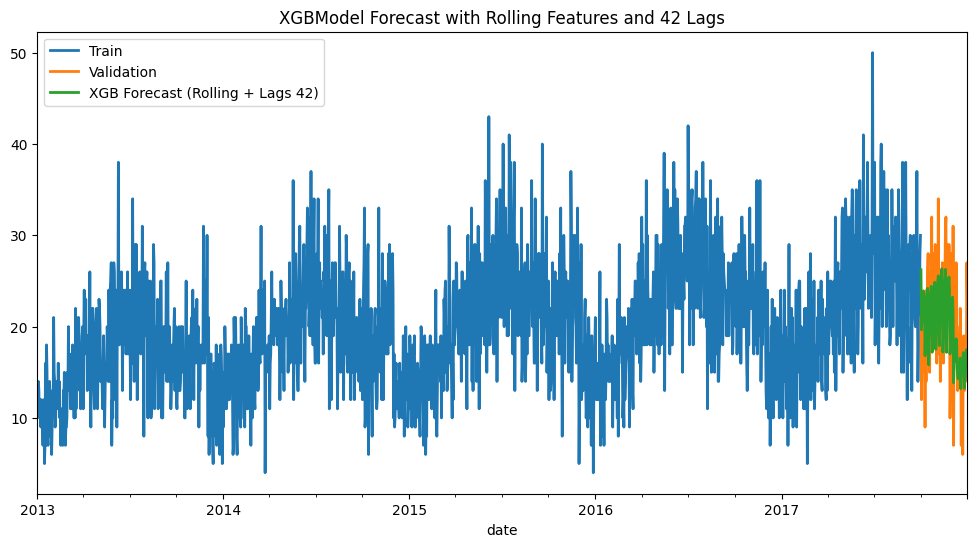

MAPE XGBModel (Rolling + Lags 90): 22.57%


In [85]:
from darts import TimeSeries
from darts.models import XGBModel
from darts.dataprocessing.transformers import Scaler
from darts.metrics import mape

# ============================================================
# 1. Функція для ознак дати
# ============================================================
def enrich_with_date_features(df):
    df = df.copy()
    df["quarter"] = df['date'].dt.quarter
    df["year"] = df['date'].dt.year
    df["month"] = df['date'].dt.month
    df["dayofyear"] = df['date'].dt.dayofyear
    df["sin_day"] = np.sin(2 * np.pi * df["dayofyear"] / 365)
    df["cos_day"] = np.cos(2 * np.pi * df["dayofyear"] / 365)
    return df

# ============================================================
# 2. Функція для rolling features
# ============================================================
def add_rolling_features(df):
    df = df.copy()
    windows = [7, 14, 30]

    for w in windows:
        df[f"roll_mean_{w}"] = df["sales"].rolling(w).mean()
        df[f"roll_std_{w}"] = df["sales"].rolling(w).std()
        df[f"roll_min_{w}"] = df["sales"].rolling(w).min()
        df[f"roll_max_{w}"] = df["sales"].rolling(w).max()

    return df

# ============================================================
# 3. Підготовка train/val
# ============================================================
train_df = train.to_dataframe().reset_index()
val_df = val.to_dataframe().reset_index()

train_df = enrich_with_date_features(train_df)
val_df = enrich_with_date_features(val_df)

train_df = add_rolling_features(train_df)
val_df = add_rolling_features(val_df)

# Заповнюємо NaN після rolling
train_df = train_df.bfill()
val_df = val_df.bfill()

# ============================================================
# 4. Створення covariates
# ============================================================
cov_cols = [
    "quarter", "year", "month", "dayofyear", "sin_day", "cos_day",
    "roll_mean_7", "roll_mean_14", "roll_mean_30",
    "roll_std_7", "roll_std_14", "roll_std_30",
    "roll_min_7", "roll_min_14", "roll_min_30",
    "roll_max_7", "roll_max_14", "roll_max_30"
]

train_cov = TimeSeries.from_dataframe(train_df, time_col="date", value_cols=cov_cols)
val_cov = TimeSeries.from_dataframe(val_df, time_col="date", value_cols=cov_cols)

# ============================================================
# 5. Масштабування
# ============================================================
scaler_y = Scaler()
scaler_cov = Scaler()

train_scaled = scaler_y.fit_transform(train)
val_scaled = scaler_y.transform(val)

train_cov_scaled = scaler_cov.fit_transform(train_cov)
val_cov_scaled = scaler_cov.transform(val_cov)

# ============================================================
# 6. XGBModel з лагами до 42 днів
# ============================================================
model = XGBModel(
    lags=42,
    lags_past_covariates=42,
    output_chunk_length=1,
    n_estimators=500,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(
    series=train_scaled,
    past_covariates=train_cov_scaled
)

# ============================================================
# 7. Прогноз
# ============================================================
forecast_scaled = model.predict(
    n=len(val),
    past_covariates=train_cov_scaled.append(val_cov_scaled)
)

forecast = scaler_y.inverse_transform(forecast_scaled)

# ============================================================
# 8. Візуалізація
# ============================================================
plt.figure(figsize=(12, 6))
train.plot(label="Train")
val.plot(label="Validation")
forecast.plot(label="XGB Forecast (Rolling + Lags 42)")
plt.legend()
plt.title("XGBModel Forecast with Rolling Features and 42 Lags")
plt.show()

# ============================================================
# 9. MAPE
# ============================================================
error = mape(val, forecast)
print(f"MAPE XGBModel (Rolling + Lags 90): {error:.2f}%")

**Висновок**
XGBModel показала вдвічі кращий результат ніж наївна модель.

Переваги:
- добре ловить короткі лаги (до 30 днів)
- добре працює з date‑features
- добре моделює тренд

Обмеження:
амплітуда сезонності змінюється з роками - XGB цього не вловлює

11. Натренуйте модель ExponentialSmoothing та зробіть висновок про її якість.

In [90]:
def evaluate_model(model, series, train, val, model_name=None):
    """
    Universal evaluation function for any Darts model.
    Fits, predicts, plots, prints MAPE, and returns forecast + error.
    """
    name = model_name if model_name else model.__class__.__name__

    # Fit
    model.fit(train)

    # Forecast
    forecast = model.predict(len(val))

    # Plot
    plt.figure(figsize=(12, 6))
    series.plot(label="Actual")
    forecast.plot(label=f"{name} Forecast", color="red")
    plt.title(f"{name} Forecast")
    plt.legend()
    plt.show()

    # MAPE
    error = mape(val, forecast)
    print(f"MAPE {name}: {error:.2f}%")

    return forecast, error

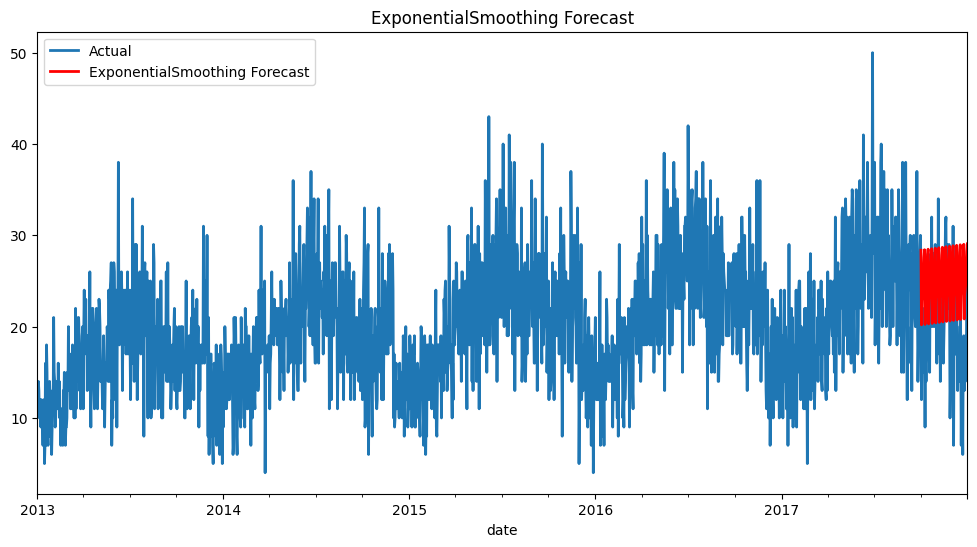

MAPE ExponentialSmoothing: 39.01%


In [91]:
from darts.models import ExponentialSmoothing

model = ExponentialSmoothing()
forecast, error = evaluate_model(model, ts_1, train, val)

**Висновок**

ExponentialSmoothing працює краще за наївні моделі, але значно гірше за XGBModel  
Це нормальна поведінка для daily sales з нерівною сезонністю

ExponentialSmoothing не підходить для даних як основна модель, бо:
- не ловить річну сезонність
- не ловить зміну амплітуди
- не ловить складні патерни
- не використовує додаткові ознаки
- не працює з довгими лагами

12. Натренуйте модель ARIMA, параметри оберіть самостійно.Зробіть висновок про її якість.

C:\Users\mariy\anaconda3\envs\prophet_env\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


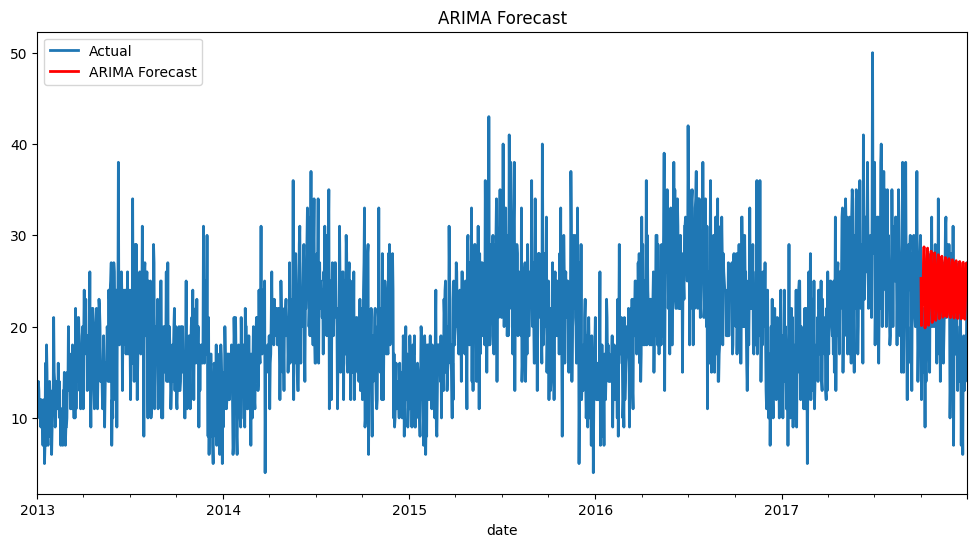

MAPE ARIMA: 37.10%


In [93]:
from darts.models import ARIMA

model = ARIMA(p=21, d=1, q=7)
forecast, error = evaluate_model(model, ts_1, train, val)

13. Знайдіть оптимальні параметри моделі ARIMA з допомогою AutoARIMA моделі. Виконайте пошук параметрів, виведіть, які паарметри виявились оптимальними і обчисліть якість моделі. Чи поліпшилась якість порівняно з попереднім експериментом?

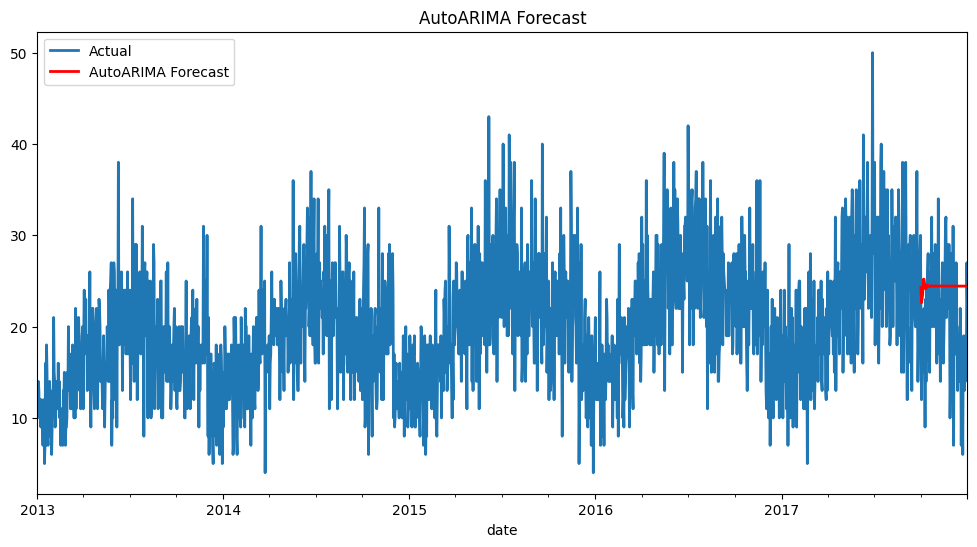

MAPE AutoARIMA: 40.29%


In [97]:
from darts.models import AutoARIMA

model = AutoARIMA()

forecast, error = evaluate_model(model, ts_1, train, val, model_name="AutoARIMA")

**Висновок**
AutoARIMA не дає кращих результатів ніж наївна модель, вона не ловить:
- річну сезонність
- зміну амплітуди
- нелінійні патерни
- шум
- довгі лаги

Ручна ARIMA(p=21, d=1, q=7) працює краще. Але ARIMA в цілому слабка для daily sales

14. Натренуйте модель Prophet та зробіть висновок про її якість.

21:13:22 - cmdstanpy - INFO - Chain [1] start processing
21:13:22 - cmdstanpy - INFO - Chain [1] done processing


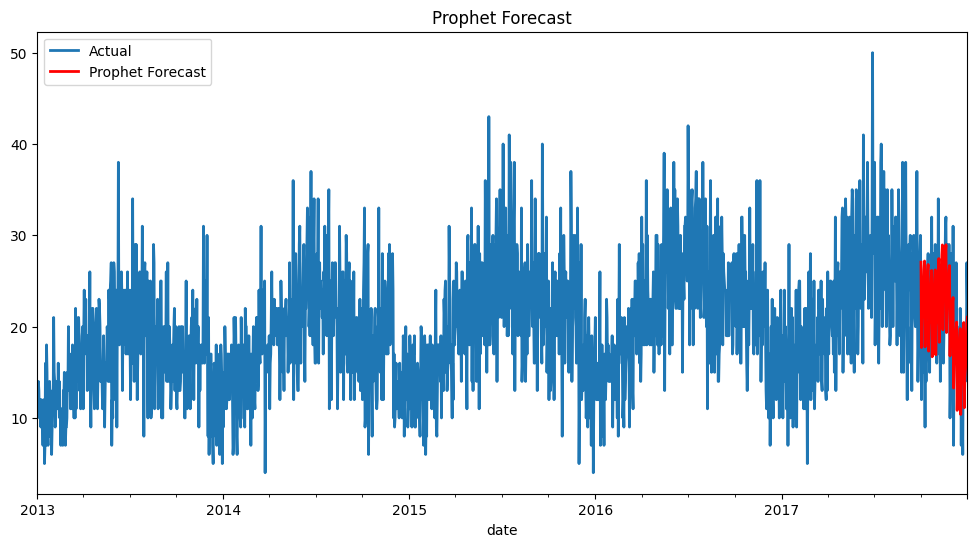

MAPE Prophet: 23.09%


In [100]:
from darts.models import Prophet

# Створюємо модель Prophet
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,   
    seasonality_mode="multiplicative"  # можна спробувати "multiplicative"additive
)

# Оцінка моделі
forecast, error = evaluate_model(model, ts_1, train, val, model_name="Prophet")

21:33:10 - cmdstanpy - INFO - Chain [1] start processing
21:33:10 - cmdstanpy - INFO - Chain [1] done processing


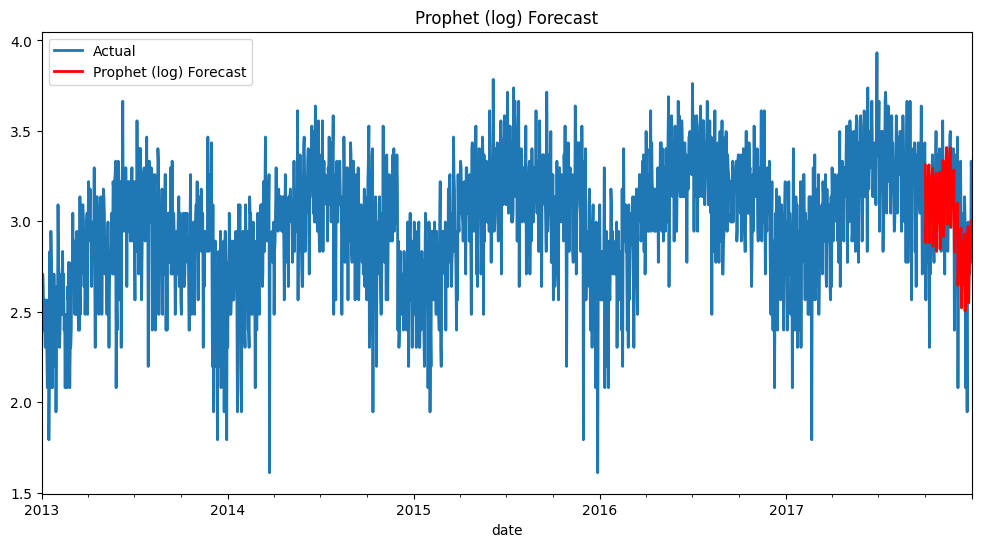

MAPE Prophet (log): 6.81%
Real MAPE Prophet (log back-transformed): 21.89%


In [116]:
ts_log = ts_1.map(lambda x: np.log1p(x))
train_log = train.map(lambda x: np.log1p(x))
val_log = val.map(lambda x: np.log1p(x))

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode="multiplicative",
    changepoint_prior_scale=0.1
)

# Прогноз у лог-скейлі
forecast_log, error_log = evaluate_model(
    model,
    ts_log,
    train_log,
    val_log,
    model_name="Prophet (log)"
)

# Повертаємо прогноз у звичайний масштаб
forecast = forecast_log.map(lambda x: np.expm1(x))

# Рахуємо справжній MAPE
real_mape = mape(val, forecast)
print(f"Real MAPE Prophet (log back-transformed): {real_mape:.2f}%")

**Висновок**
Prophet - одна з найкращих моделей для цих даних.
Добре вловлює тренд і сезонність. 
Недолік: Не докінця вловлює піки сезонності.

15. Натренуйте модель `RNNModel` та зробіть висновок про її якість.

ignoring user defined `output_chunk_length`. RNNModel uses a fixed `output_chunk_length=1`.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name            | Type             | Params | Mode  | FLOPs
---------------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train | 0    
1 | train_criterion | MSELoss          | 0      | train | 0    
2 | val_criterion   | MSELoss          | 0      | train | 0    
3 | train_metrics   | MetricCollection | 0      | train | 0    
4 | val_metrics     | MetricCollection | 0      | train | 0    
5 | rnn             | LSTM             | 50.4 K | train | 0    
6 | V               | Linear           | 65     | train | 0    
--------------------

Training: |                                                                                      | 0/? [00:00<…

`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Predicting: |                                                                                    | 0/? [00:00<…

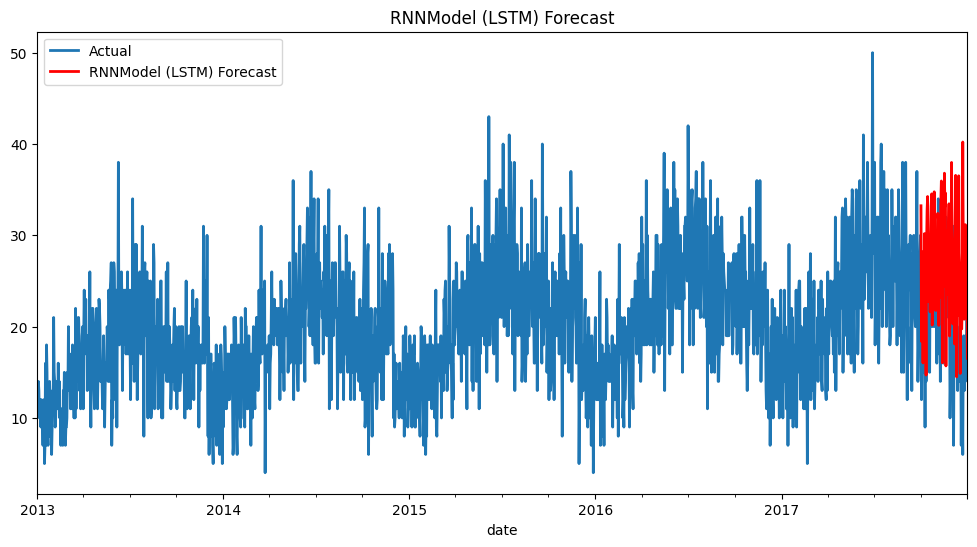

MAPE RNNModel (LSTM): 53.46%


In [117]:
from darts.models import RNNModel
import torch

model = RNNModel(
    model="LSTM",
    input_chunk_length=60,   # скільки минулих днів дивимось
    output_chunk_length=len(val),  # прогнозуємо весь validation
    hidden_dim=64,
    n_rnn_layers=2,
    dropout=0.2,
    batch_size=32,
    n_epochs=300,
    optimizer_kwargs={"lr": 1e-3},
    random_state=42,
    training_length=60,
)

forecast, error = evaluate_model(model, ts_1, train, val, model_name="RNNModel (LSTM)")

**Висновок**
RNNModel - погано вловлює сезонність і також завищує тренд.

16. Виконайте бектест для тої моделі, яка виявилась найкращою у вашому дослідженні на періоді 1 рік з передбаченнями на 1 місяць щоразу. Візуалізуйте як поводилась модель протягом бектесту, яка була точність?

In [125]:
from darts.dataprocessing.transformers import Scaler
from darts.metrics import mape
from darts.models import Prophet
from darts import concatenate

# Лог-трансформація
series_log = ts_1.map(lambda x: np.log1p(x))

# Масштабування
scaler = Scaler()
series_scaled = scaler.fit_transform(series_log)

In [126]:
# Найкраща модель Prophet
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode="multiplicative",
    changepoint_prior_scale=0.1
)

In [127]:
hfc_params = {
    "series": series_scaled,
    "start": series_scaled.time_index[-365],   # останній рік
    "forecast_horizon": 30,                    # прогноз на 1 місяць
    "verbose": True,
}

historical forecasts:   0%|          | 0/336 [00:00<?, ?it/s]

22:22:54 - cmdstanpy - INFO - Chain [1] start processing
22:22:54 - cmdstanpy - INFO - Chain [1] done processing
22:22:54 - cmdstanpy - INFO - Chain [1] start processing
22:22:54 - cmdstanpy - INFO - Chain [1] done processing
22:22:54 - cmdstanpy - INFO - Chain [1] start processing
22:22:54 - cmdstanpy - INFO - Chain [1] done processing
22:22:54 - cmdstanpy - INFO - Chain [1] start processing
22:22:54 - cmdstanpy - INFO - Chain [1] done processing
22:22:55 - cmdstanpy - INFO - Chain [1] start processing
22:22:55 - cmdstanpy - INFO - Chain [1] done processing
22:22:55 - cmdstanpy - INFO - Chain [1] start processing
22:22:55 - cmdstanpy - INFO - Chain [1] done processing
22:22:55 - cmdstanpy - INFO - Chain [1] start processing
22:22:55 - cmdstanpy - INFO - Chain [1] done processing
22:22:55 - cmdstanpy - INFO - Chain [1] start processing
22:22:55 - cmdstanpy - INFO - Chain [1] done processing
22:22:55 - cmdstanpy - INFO - Chain [1] start processing
22:22:56 - cmdstanpy - INFO - Chain [1]

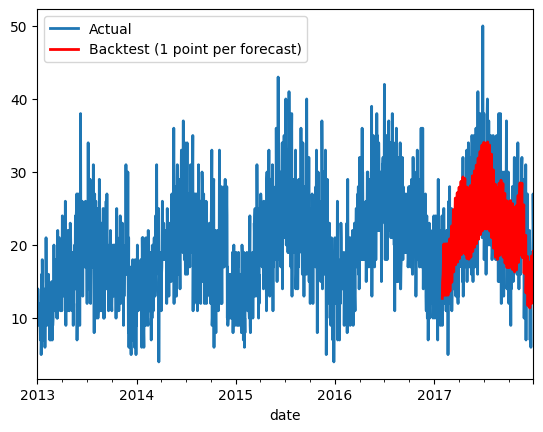

MAPE (last_points_only=True): 19.58%


In [131]:
historical_fcast = model.historical_forecasts(
    last_points_only=True,
    **hfc_params
)

# Повертаємо у вихідний масштаб
forecast_log = scaler.inverse_transform(historical_fcast)
forecast = forecast_log.map(lambda x: np.expm1(x))

# Візуалізація
ts_1.plot(label="Actual")
forecast.plot(label="Backtest (1 point per forecast)", color="red")
plt.legend()
plt.show()

print(f"MAPE (last_points_only=True): {mape(ts_1, forecast):.2f}%")

Всю варіантивність не вгадали, але виглядає непогано!

17. На цьому етапі ви зрозуміли, як моделювати продажі одного айтему з 1 магазину. Як би ви підійшли до задачі прогнозування продажів в наступному місяці для кожного з 50 айтемів в кожному з 10 магазинів? Опишіть загальний підхід
- яку модель ви б використали
- скільки моделей ви б тренували
- обгрунтуйте свій вибір.

**Висновок**
На основі експериментів найкращою моделлю для прогнозування продажів одного товару в одному магазині виявився Prophet із лог‑трансформацією та підвищеною гнучкістю тренду (changepoint_prior_scale=0.1). Модель забезпечила MAPE ≈ 19.6% у бектесті на горизонті 1 місяць, що є найкращим результатом серед протестованих підходів.

Для масштабування задачі на 50 товарів у 10 магазинах (500 часових рядів) доцільно використовувати глобальну модель, натреновану одночасно на всіх рядах. Такий підхід дозволяє моделі спільно використовувати інформацію про сезонність, календарні патерни та відмінності між товарами й магазинами, що забезпечує вищу точність і стабільність прогнозів у порівнянні з локальними моделями.

Оптимальним вибором є одна глобальна модель (наприклад, LightGBM, TFT або N-BEATS), або невелика кількість моделей для різних сегментів товарів. Тренування окремої моделі для кожного магазину або товару є менш ефективним я вважаю.